# 1. Initial setup and Dataset download



In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_36426578a454fe05575213ee922f0e2e"

: 

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets list -s audio

ref                                                      title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
uwrfkaggler/ravdess-emotional-speech-audio               RAVDESS Emotional speech audio                     450102890  2019-01-19 18:28:31.433000         109542        729  0.875            
sripaadsrinivasan/audio-mnist                            Audio MNIST                                        994530111  2020-12-28 07:34:33.170000           7515         74  0.875            
mmoreaux/audio-cats-and-dogs                             Audio Cats and Dogs                                101721956  2017-10-05 09:40:26.727000          19079        289  0.7647059        
uldisvalainis/audio-emotions                 

In [ ]:
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [06:51<00:00, 41.8MB/s]



In [ ]:
!ls -lh

total 17G
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data
-rw-r--r-- 1 root root  17G Apr 16  2024 the-fake-or-real-dataset.zip


In [ ]:
!du -sh the-fake-or-real-dataset.zip

17G	the-fake-or-real-dataset.zip


In [ ]:
!unzip -q the-fake-or-real-dataset.zip -d dataset

In [ ]:
!ls dataset

for-2sec  for-norm  for-original  for-rerec


In [ ]:
import os

root = "/content/dataset"

for current_root, dirs, files in os.walk(root):
    level = current_root.replace(root, "").count(os.sep)

    if level > 3:
        continue

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(current_root)}/")

    subindent = " " * 4 * (level + 1)

    for d in dirs[:10]:
        print(f"{subindent}{d}/")

dataset/
    for-rerec/
    for-2sec/
    for-norm/
    for-original/
    for-rerec/
        for-rerecorded/
        for-rerecorded/
            training/
            testing/
            validation/
            training/
                real/
                fake/
            testing/
                real/
                fake/
            validation/
                real/
                fake/
    for-2sec/
        for-2seconds/
        for-2seconds/
            training/
            testing/
            validation/
            training/
                real/
                fake/
            testing/
                real/
                fake/
            validation/
                real/
                fake/
    for-norm/
        for-norm/
        for-norm/
            training/
            testing/
            validation/
            training/
                real/
                fake/
            testing/
                real/
                fake/
            validation/
     

In [ ]:
from pathlib import Path

root = Path("/content/dataset")

for item in root.iterdir():
    print(item)

/content/dataset/for-rerec
/content/dataset/for-2sec
/content/dataset/for-norm
/content/dataset/for-original


In [ ]:
from pathlib import Path

base = Path("/content/dataset/for-2sec/for-2seconds")

train_real = len(list((base / "training" / "real").glob("*.wav")))
train_fake = len(list((base / "training" / "fake").glob("*.wav")))

val_real = len(list((base / "validation" / "real").glob("*.wav")))
val_fake = len(list((base / "validation" / "fake").glob("*.wav")))

test_real = len(list((base / "testing" / "real").glob("*.wav")))
test_fake = len(list((base / "testing" / "fake").glob("*.wav")))

print("TRAIN")
print("Real:", train_real)
print("Fake:", train_fake)

print("\nVALIDATION")
print("Real:", val_real)
print("Fake:", val_fake)

print("\nTEST")
print("Real:", test_real)
print("Fake:", test_fake)

TRAIN
Real: 6978
Fake: 6978

VALIDATION
Real: 1413
Fake: 1413

TEST
Real: 544
Fake: 544


In [ ]:
import librosa

sample_file = next(
    (base / "training" / "real").glob("*.wav")
)

audio, sr = librosa.load(
    sample_file,
    sr=None
)

print("Sample Rate:", sr)
print("Duration:", len(audio) / sr)

Sample Rate: 16000
Duration: 2.0


In [ ]:
!pip install librosa pandas numpy scikit-learn tqdm

# 2. Libraries Import

In [ ]:
import librosa
import numpy as np

In [ ]:
audio, sr = librosa.load(sample_file, sr=None)

print(audio.shape)
print(sr)

(32000,)
16000


**Extract MFCC**

In [ ]:
mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print(mfccs.shape)

(13, 63)


In [ ]:
mfcc_mean = np.mean(
    mfccs,
    axis=1
)

print(mfcc_mean.shape)
print(mfcc_mean)

(13,)
[-1.98476517e+02  5.48018074e+01  6.32517576e+00  1.31589737e+01
 -3.07108269e+01 -2.59175625e+01 -3.20256310e+01 -1.54961233e+01
 -1.28369827e+01 -1.43443775e+01 -1.78170929e+01 -8.28710079e+00
 -1.78161979e-01]


In [ ]:
mfcc_std = np.std(
    mfccs,
    axis=1
)

print(mfcc_std.shape)

(13,)


In [ ]:
mfcc_features = np.concatenate([
    mfcc_mean,
    mfcc_std
])

print(mfcc_features.shape)

(26,)


In [ ]:
print(mfcc_features)

[-1.98476517e+02  5.48018074e+01  6.32517576e+00  1.31589737e+01
 -3.07108269e+01 -2.59175625e+01 -3.20256310e+01 -1.54961233e+01
 -1.28369827e+01 -1.43443775e+01 -1.78170929e+01 -8.28710079e+00
 -1.78161979e-01  9.79637146e+01  8.02250519e+01  4.88377457e+01
  2.57859421e+01  2.23428459e+01  1.63858261e+01  1.50559282e+01
  1.56357918e+01  1.11971083e+01  1.44321146e+01  1.12174292e+01
  9.22651768e+00  7.49976778e+00]


**Zero Crossing Rate (ZCR)**

In [ ]:
zcr = librosa.feature.zero_crossing_rate(audio)

print(zcr.shape)

(1, 63)


In [ ]:
zcr_mean = np.mean(zcr)
print(zcr_mean)

0.20541914682539683


In [ ]:
zcr_std = np.std(zcr)
print(zcr_std)

0.16104242658040752


In [ ]:
zcr_features = np.array([
    zcr_mean,
    zcr_std
])

print(zcr_features.shape)

(2,)


**Spectral Centroid**

In [ ]:
centroid = librosa.feature.spectral_centroid(
    y=audio,
    sr=sr
)

print(centroid.shape)

(1, 63)


In [ ]:
centroid_mean = np.mean(centroid)
centroid_std = np.std(centroid)

centroid_features = np.array([
    centroid_mean,
    centroid_std
])

print(centroid_features.shape)

(2,)


**Spectral Bandwidth**

In [ ]:
bandwidth = librosa.feature.spectral_bandwidth(
    y=audio,
    sr=sr
)

print(bandwidth.shape)

(1, 63)


In [ ]:
bandwidth_mean = np.mean(bandwidth)
bandwidth_std = np.std(bandwidth)

bandwidth_features = np.array([
    bandwidth_mean,
    bandwidth_std
])

print(bandwidth_features.shape)

(2,)


**Chroma Features**

In [ ]:
chroma = librosa.feature.chroma_stft(
    y=audio,
    sr=sr
)

print(chroma.shape)

(12, 63)


In [ ]:
chroma_mean = np.mean(
    chroma,
    axis=1
)

print(chroma_mean.shape)

(12,)


**Final Feature Vector**

In [ ]:
feature_vector = np.concatenate([
    mfcc_features,
    zcr_features,
    centroid_features,
    bandwidth_features,
    chroma_mean
])

print(feature_vector.shape)

(44,)


# 3. Create extract_features() Function

In [ ]:
import librosa
import numpy as np

def extract_features(audio_path):
    """
    Extract 44 audio features from a WAV file.

    Features:
    - 13 MFCC means
    - 13 MFCC stds
    - ZCR mean + std
    - Spectral Centroid mean + std
    - Spectral Bandwidth mean + std
    - 12 Chroma means

    Total = 44 features
    """

    try:
        # Load audio
        audio, sr = librosa.load(audio_path, sr=None)

        # -------------------------
        # MFCC
        # -------------------------
        mfccs = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=13
        )

        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std = np.std(mfccs, axis=1)

        mfcc_features = np.concatenate([
            mfcc_mean,
            mfcc_std
        ])

        # -------------------------
        # Zero Crossing Rate
        # -------------------------
        zcr = librosa.feature.zero_crossing_rate(audio)

        zcr_features = np.array([
            np.mean(zcr),
            np.std(zcr)
        ])

        # -------------------------
        # Spectral Centroid
        # -------------------------
        centroid = librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )

        centroid_features = np.array([
            np.mean(centroid),
            np.std(centroid)
        ])

        # -------------------------
        # Spectral Bandwidth
        # -------------------------
        bandwidth = librosa.feature.spectral_bandwidth(
            y=audio,
            sr=sr
        )

        bandwidth_features = np.array([
            np.mean(bandwidth),
            np.std(bandwidth)
        ])

        # -------------------------
        # Chroma
        # -------------------------
        chroma = librosa.feature.chroma_stft(
            y=audio,
            sr=sr
        )

        chroma_mean = np.mean(
            chroma,
            axis=1
        )

        # -------------------------
        # Final Feature Vector
        # -------------------------
        feature_vector = np.concatenate([
            mfcc_features,        # 26
            zcr_features,         # 2
            centroid_features,    # 2
            bandwidth_features,   # 2
            chroma_mean           # 12
        ])

        return feature_vector

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")

        # Return zeros so pipeline doesn't crash
        return np.zeros(44)

**Metadata DataFrame**

In [ ]:
real_files = list(
    Path(
        "/content/dataset/for-2sec/for-2seconds/training/real"
    ).glob("*.wav")
)

print(len(real_files))

fake_files = list(
    Path(
        "/content/dataset/for-2sec/for-2seconds/training/fake"
    ).glob("*.wav")
)

print(len(fake_files))

6978
6978


In [ ]:
records = []

for file in real_files:

    records.append(
        {
            "filepath": str(file),
            "label": 0
        }
    )

for file in fake_files:

    records.append(
        {
            "filepath": str(file),
            "label": 1
        }
    )

**Dataframe Created**

In [ ]:
import pandas as pd

df = pd.DataFrame(records)

In [ ]:
df.head()


,filepath,label
0,/content/dataset/for-2sec/for-2seconds/trainin...,0
1,/content/dataset/for-2sec/for-2seconds/trainin...,0
2,/content/dataset/for-2sec/for-2seconds/trainin...,0
3,/content/dataset/for-2sec/for-2seconds/trainin...,0
4,/content/dataset/for-2sec/for-2seconds/trainin...,0


In [ ]:
print(df.shape)

(13956, 2)


In [ ]:
df["label"].value_counts()

,count
label,
0,6978
1,6978


***Sample DataFrame***

In [ ]:
sample_df = pd.concat([
    df[df["label"] == 0].head(100),
    df[df["label"] == 1].head(100)
])

print(sample_df.shape)

(200, 2)


In [ ]:
sample_df["label"].value_counts()

,count
label,
0,100
1,100


**Feature Rows Creation**

In [ ]:
feature_rows = []

In [ ]:
from tqdm import tqdm

In [ ]:
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    path = row["filepath"]

    label = row["label"]

    features = extract_features(path)

    row_data = list(features)

    row_data.append(label)

    feature_rows.append(row_data)

 45%|████▌     | 90/200 [00:08<00:10, 10.19it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 200/200 [00:19<00:00, 10.51it/s]


In [ ]:
features_df = pd.DataFrame(feature_rows)

print(features_df.shape)

(200, 45)


In [ ]:
features_df.isnull().sum().sum()
np.isinf(features_df).sum().sum()

np.int64(0)

In [ ]:
feature_columns = [
    f"feature_{i}"
    for i in range(1, 45)
]

feature_columns.append("label")

print(len(feature_columns))

45


In [ ]:
features_df = pd.DataFrame(
    feature_rows,
    columns=feature_columns
)

In [ ]:
features_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,label
0,-198.476517,54.801807,6.325176,13.158974,-30.710827,-25.917562,-32.025631,-15.496123,-12.836983,-14.344378,...,0.452220,0.387760,0.333479,0.305393,0.307070,0.365835,0.317070,0.303988,0.304999,0
1,-90.837814,41.292828,38.758663,15.437077,7.586430,-9.597175,9.420567,-11.545800,-4.840878,-12.612426,...,0.187768,0.183366,0.249939,0.321789,0.350799,0.385337,0.562581,0.557574,0.349386,0
2,-225.668701,85.219093,2.175019,29.901764,-0.101837,9.266059,-0.806880,8.296430,-0.508456,4.538924,...,0.586089,0.615560,0.551116,0.452888,0.410504,0.344586,0.370855,0.386968,0.368371,0
3,-185.502670,99.229843,28.352659,43.253860,-7.512129,8.742493,-6.101886,2.323481,-11.773946,11.643311,...,0.326511,0.300178,0.312563,0.473127,0.524595,0.395135,0.375183,0.439680,0.569340,0
4,-250.153885,51.324215,17.176165,-10.710394,-26.373379,-6.206735,-20.351343,-24.148787,1.441377,-12.847934,...,0.312181,0.256646,0.180185,0.200452,0.231571,0.359452,0.504556,0.288324,0.177101,0


In [ ]:
features_df.to_csv(
    "features_sample.csv",
    index=False
)

# 4. Model Training

**1. Random Forest**

In [ ]:
features_df = pd.read_csv(
    "features_sample.csv"
)

features_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,label
0,-198.476517,54.801807,6.325176,13.158974,-30.710827,-25.917562,-32.025631,-15.496123,-12.836983,-14.344378,...,0.452220,0.387760,0.333479,0.305393,0.307070,0.365835,0.317070,0.303988,0.304999,0
1,-90.837814,41.292828,38.758663,15.437077,7.586430,-9.597175,9.420567,-11.545800,-4.840878,-12.612426,...,0.187768,0.183366,0.249939,0.321789,0.350799,0.385337,0.562581,0.557574,0.349386,0
2,-225.668701,85.219093,2.175019,29.901764,-0.101837,9.266059,-0.806880,8.296430,-0.508456,4.538924,...,0.586089,0.615560,0.551116,0.452888,0.410504,0.344586,0.370855,0.386968,0.368371,0
3,-185.502670,99.229843,28.352659,43.253860,-7.512129,8.742493,-6.101886,2.323481,-11.773946,11.643311,...,0.326511,0.300178,0.312563,0.473127,0.524595,0.395135,0.375183,0.439680,0.569340,0
4,-250.153885,51.324215,17.176165,-10.710394,-26.373379,-6.206735,-20.351343,-24.148787,1.441377,-12.847934,...,0.312181,0.256646,0.180185,0.200452,0.231571,0.359452,0.504556,0.288324,0.177101,0


In [ ]:
print(features_df.shape)

(200, 45)


Separate Features and Labels

In [ ]:
X = features_df.drop(
    columns=["label"]
)

y = features_df["label"]

In [ ]:
print(X.shape)
print(y.shape)

(200, 44)
(200,)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(160, 44)
(40, 44)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(X_train_scaled.shape)

(160, 44)


Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(
    X_test_scaled
)

y_pred

array([0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0])

Calculate Accuracy

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

0.85
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.82      0.90      0.86        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40

[[16  4]
 [ 2 18]]


**Training on full dataset**

In [ ]:
feature_rows = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Extracting Features"
):
    path = row["filepath"]

    label = row["label"]

    features = extract_features(path)

    row_data = list(features)

    row_data.append(label)

    feature_rows.append(row_data)

Extracting Features:   1%|          | 91/13956 [00:05<14:46, 15.64it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
Extracting Features: 100%|██████████| 13956/13956 [08:09<00:00, 28.53it/s]


In [ ]:
features_df = pd.DataFrame(feature_rows)

print(features_df.shape)

(13956, 45)


In [ ]:
features_df.isnull().sum().sum()
np.isinf(features_df).sum().sum()

np.int64(0)

In [ ]:
feature_columns = [
    f"feature_{i}"
    for i in range(1, 45)
]

feature_columns.append("label")

print(len(feature_columns))

45


In [ ]:
features_df = pd.DataFrame(
    feature_rows,
    columns=feature_columns
)

In [ ]:
features_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,label
0,-198.476517,54.801807,6.325176,13.158974,-30.710827,-25.917562,-32.025631,-15.496123,-12.836983,-14.344378,...,0.452220,0.387760,0.333479,0.305393,0.307070,0.365835,0.317070,0.303988,0.304999,0
1,-90.837814,41.292828,38.758663,15.437077,7.586430,-9.597175,9.420567,-11.545800,-4.840878,-12.612426,...,0.187768,0.183366,0.249939,0.321789,0.350799,0.385337,0.562581,0.557574,0.349386,0
2,-225.668701,85.219093,2.175019,29.901764,-0.101837,9.266059,-0.806880,8.296430,-0.508456,4.538924,...,0.586089,0.615560,0.551116,0.452888,0.410504,0.344586,0.370855,0.386968,0.368371,0
3,-185.502670,99.229843,28.352659,43.253860,-7.512129,8.742493,-6.101886,2.323481,-11.773946,11.643311,...,0.326511,0.300178,0.312563,0.473127,0.524595,0.395135,0.375183,0.439680,0.569340,0
4,-250.153885,51.324215,17.176165,-10.710394,-26.373379,-6.206735,-20.351343,-24.148787,1.441377,-12.847934,...,0.312181,0.256646,0.180185,0.200452,0.231571,0.359452,0.504556,0.288324,0.177101,0


In [ ]:
features_df.to_csv(
    "features_full.csv",
    index=False
)

In [ ]:
features_df = pd.read_csv(
    "features_full.csv"
)

features_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,label
0,-198.476517,54.801807,6.325176,13.158974,-30.710827,-25.917562,-32.025631,-15.496123,-12.836983,-14.344378,...,0.452220,0.387760,0.333479,0.305393,0.307070,0.365835,0.317070,0.303988,0.304999,0
1,-90.837814,41.292828,38.758663,15.437077,7.586430,-9.597175,9.420567,-11.545800,-4.840878,-12.612426,...,0.187768,0.183366,0.249939,0.321789,0.350799,0.385337,0.562581,0.557574,0.349386,0
2,-225.668701,85.219093,2.175019,29.901764,-0.101837,9.266059,-0.806880,8.296430,-0.508456,4.538924,...,0.586089,0.615560,0.551116,0.452888,0.410504,0.344586,0.370855,0.386968,0.368371,0
3,-185.502670,99.229843,28.352659,43.253860,-7.512129,8.742493,-6.101886,2.323481,-11.773946,11.643311,...,0.326511,0.300178,0.312563,0.473127,0.524595,0.395135,0.375183,0.439680,0.569340,0
4,-250.153885,51.324215,17.176165,-10.710394,-26.373379,-6.206735,-20.351343,-24.148787,1.441377,-12.847934,...,0.312181,0.256646,0.180185,0.200452,0.231571,0.359452,0.504556,0.288324,0.177101,0


In [ ]:
X = features_df.drop(
    columns=["label"]
)

y = features_df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(X_train_scaled.shape)

(11164, 44)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf.predict(
    X_test_scaled
)

y_pred

array([1, 0, 0, ..., 1, 0, 1])

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

0.9691977077363897
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1396
           1       0.96      0.97      0.97      1396

    accuracy                           0.97      2792
   macro avg       0.97      0.97      0.97      2792
weighted avg       0.97      0.97      0.97      2792

[[1345   51]
 [  35 1361]]


In [ ]:
import joblib

joblib.dump(
    rf,
    "random_forest_model.pkl"
)

joblib.dump(
    scaler,
    "random_forest_scaler.pkl"
)

['random_forest_scaler.pkl']

**2. XGBOOST**

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
features_df = pd.read_csv("features_full.csv")

print(features_df.shape)
features_df.head()

(13956, 45)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,label
0,-198.476517,54.801807,6.325176,13.158974,-30.710827,-25.917562,-32.025631,-15.496123,-12.836983,-14.344378,...,0.452220,0.387760,0.333479,0.305393,0.307070,0.365835,0.317070,0.303988,0.304999,0
1,-90.837814,41.292828,38.758663,15.437077,7.586430,-9.597175,9.420567,-11.545800,-4.840878,-12.612426,...,0.187768,0.183366,0.249939,0.321789,0.350799,0.385337,0.562581,0.557574,0.349386,0
2,-225.668701,85.219093,2.175019,29.901764,-0.101837,9.266059,-0.806880,8.296430,-0.508456,4.538924,...,0.586089,0.615560,0.551116,0.452888,0.410504,0.344586,0.370855,0.386968,0.368371,0
3,-185.502670,99.229843,28.352659,43.253860,-7.512129,8.742493,-6.101886,2.323481,-11.773946,11.643311,...,0.326511,0.300178,0.312563,0.473127,0.524595,0.395135,0.375183,0.439680,0.569340,0
4,-250.153885,51.324215,17.176165,-10.710394,-26.373379,-6.206735,-20.351343,-24.148787,1.441377,-12.847934,...,0.312181,0.256646,0.180185,0.200452,0.231571,0.359452,0.504556,0.288324,0.177101,0


In [ ]:
X = features_df.drop(columns=["label"])

y = features_df["label"]

print(X.shape)
print(y.shape)

(13956, 44)
(13956,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(11164, 44)
(2792, 44)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
xgb.fit(
    X_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb.predict(
    X_test_scaled
)

y_pred

array([1, 0, 0, ..., 1, 0, 1])

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

Accuracy: 0.9782
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1396
           1       0.97      0.99      0.98      1396

    accuracy                           0.98      2792
   macro avg       0.98      0.98      0.98      2792
weighted avg       0.98      0.98      0.98      2792

[[1355   41]
 [  20 1376]]


In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(10))

       feature  importance
19  feature_20    0.108087
25  feature_26    0.073366
34  feature_35    0.049985
5    feature_6    0.049971
30  feature_31    0.044376
12  feature_13    0.037558
21  feature_22    0.035256
16  feature_17    0.034960
9   feature_10    0.031651
24  feature_25    0.031429


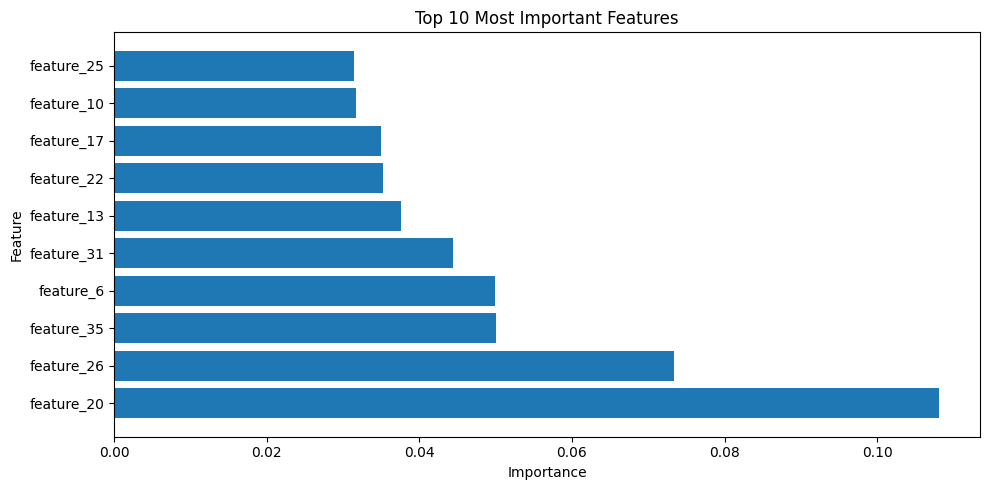

In [ ]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10["feature"],
    top10["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(
    xgb,
    "xgboost_model.pkl"
)

joblib.dump(
    scaler,
    "xgboost_scaler.pkl"
)

['xgboost_scaler.pkl']

In [ ]:
train_pred = xgb.predict(X_train_scaled)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", accuracy)

Train Accuracy: 0.9993729845933357
Test Accuracy: 0.9781518624641834


In [ ]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Predicted probabilities
y_scores = xgb.predict_proba(X_test_scaled)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Equal Error Rate
eer = brentq(
    lambda x: 1.0 - x - interp1d(fpr, tpr)(x),
    0.0,
    1.0
)

print(f"EER: {eer:.4f}")
print(f"EER (%): {eer * 100:.2f}%")

EER: 0.0179
EER (%): 1.79%


with stronger config

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
xgb.fit(
    X_train_scaled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb.predict(
    X_test_scaled
)


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

Accuracy: 0.9828
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1396
           1       0.98      0.99      0.98      1396

    accuracy                           0.98      2792
   macro avg       0.98      0.98      0.98      2792
weighted avg       0.98      0.98      0.98      2792

[[1364   32]
 [  16 1380]]


In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(10))

       feature  importance
19  feature_20    0.083053
25  feature_26    0.066310
5    feature_6    0.052256
16  feature_17    0.049225
34  feature_35    0.046331
30  feature_31    0.043003
12  feature_13    0.035446
9   feature_10    0.031217
21  feature_22    0.028329
24  feature_25    0.027353


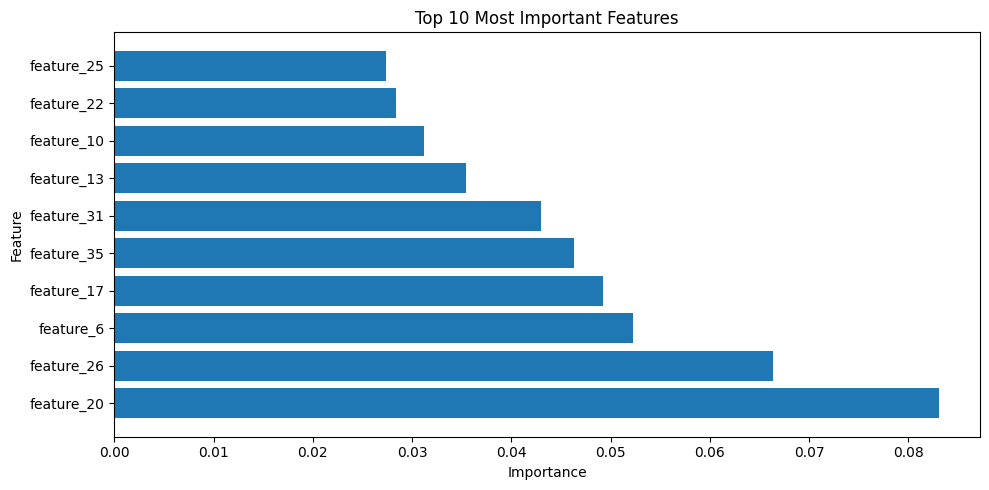

In [ ]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10["feature"],
    top10["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(
    xgb,
    "xgboost_model_optimized.pkl"
)

joblib.dump(
    scaler,
    "xgboost_scaler_optimized.pkl"
)

['xgboost_scaler_optimized.pkl']

In [ ]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [ ]:
train_pred = xgb.predict(X_train_scaled)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", accuracy)

Train Accuracy: 1.0
Test Accuracy: 0.9828080229226361


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

[0.98244986 0.98781799 0.98530992 0.98351845 0.9867431 ]
Mean Accuracy: 0.9851678645749387
Std: 0.0019815564680256566


In [ ]:
y_prob = xgb.predict_proba(X_test_scaled)

print(y_prob[:5])

[[1.06811523e-04 9.99893188e-01]
 [8.77206206e-01 1.22793764e-01]
 [9.93733466e-01 6.26651058e-03]
 [9.95363951e-01 4.63605532e-03]
 [6.30080700e-04 9.99369919e-01]]


In [ ]:
import sklearn
import joblib
import numpy

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.6.1
joblib: 1.5.3
numpy: 2.0.2


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("features_full.csv")

X = df.drop(columns=["label"])

scaler = StandardScaler()
scaler.fit(X)

joblib.dump(
    scaler,
    "xgboost_scaler_optimized_new.pkl"
)

['xgboost_scaler_optimized_new.pkl']

In [ ]:
scaler = joblib.load(
    "xgboost_scaler_optimized_new.pkl"
)

print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [ ]:
import joblib

joblib.dump(
    {
        "model": xgb,
        "scaler": scaler
    },
    "deepfake_detector_bundle.pkl"
)

['deepfake_detector_bundle.pkl']

In [ ]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Predicted probabilities
y_scores = xgb.predict_proba(X_test_scaled)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Equal Error Rate
eer = brentq(
    lambda x: 1.0 - x - interp1d(fpr, tpr)(x),
    0.0,
    1.0
)

print(f"EER: {eer:.4f}")
print(f"EER (%): {eer * 100:.2f}%")

EER: 0.0179
EER (%): 1.79%


In [ ]:
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Predicted probabilities
y_scores = rf.predict_proba(X_test_scaled)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Equal Error Rate
eer = brentq(
    lambda x: 1.0 - x - interp1d(fpr, tpr)(x),
    0.0,
    1.0
)

print(f"EER: {eer:.4f}")
print(f"EER (%): {eer * 100:.2f}%")

EER: 0.0301
EER (%): 3.01%
